# Student performance & placement — EDA

Dataset: [shambhurajejagadale/student-performance-prediction-dataset](https://www.kaggle.com/datasets/shambhurajejagadale/student-performance-prediction-dataset) (CSV: `student_dataset_10000_rows.csv`).

Goal: summarize behaviors and prior scores versus **exam_score** and **placement_status** for downstream prediction or policy-style questions (what aligns with placement?).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import kagglehub
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)

CSV_BASENAME = "student_dataset_10000_rows.csv"
KAGGLE_SLUG = "shambhurajejagadale/student-performance-prediction-dataset"

EXPECTED_COLS = [
    "study_hours",
    "attendance",
    "sleep_hours",
    "internet_usage",
    "assignments_completed",
    "previous_score",
    "exam_score",
    "placement_status",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        cands = [p for p in kaggle_root.rglob("*.csv") if p.is_file()]
        if cands:
            p = max(cands, key=lambda x: x.stat().st_size)
            assert p.is_file()
            return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    assert p.exists(), f"expected {CSV_BASENAME} under {root}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
extra = set(df.columns) - set(EXPECTED_COLS)
assert not missing, f"missing columns: {sorted(missing)}"
assert not extra, f"unexpected columns: {sorted(extra)}"
assert df.shape[0] == 10_000
assert df.shape[1] == len(EXPECTED_COLS)

NUM_COLS = [c for c in df.columns if c != "placement_status"]
CAT_COLS = ["placement_status"]

print(df.shape[0], "rows ×", df.shape[1], "cols")
display(df.sample(5, random_state=7))
display(df.dtypes)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CSV: /Users/nicapotato/.cache/kagglehub/datasets/shambhurajejagadale/student-performance-prediction-dataset/versions/1/student_dataset_10000_rows.csv
10000 rows × 8 cols


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
1977,6,65,6,6,20,66,100.00,Placed
3880,8,50,8,3,14,67,100.00,Placed
52,4,100,6,8,15,44,100.00,Placed
2551,11,97,6,10,7,66,100.00,Placed
2246,6,95,9,2,8,38,94.64,Placed


study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status             str
dtype: object

## Univariate analysis

**placement_status** is the only true categorical field. The rest are integer-like behaviors or scores (treat as numeric/metric); **exam_score** is float.

**Agent read:** class balance matters for classification — note the Placed vs Not Placed split before training or interpreting raw accuracy.



=== placement_status ===


,count,pct
placement_status,,
Placed,8356,83.6
Not Placed,1644,16.4


,count,mean,std,min,25%,50%,75%,max
study_hours,10000.0,5.989600,3.163589,1.00,3.0000,6.00,9.0,11.0
attendance,10000.0,69.884600,17.616530,40.00,55.0000,70.00,85.0,100.0
sleep_hours,10000.0,6.498500,1.709354,4.00,5.0000,6.50,8.0,9.0
internet_usage,10000.0,6.062600,3.138163,1.00,3.0000,6.00,9.0,11.0
assignments_completed,10000.0,9.988400,6.034145,0.00,5.0000,10.00,15.0,20.0
previous_score,10000.0,64.911000,17.503020,35.00,50.0000,65.00,80.0,95.0
exam_score,10000.0,86.704207,15.058383,26.67,76.7275,92.12,100.0,100.0


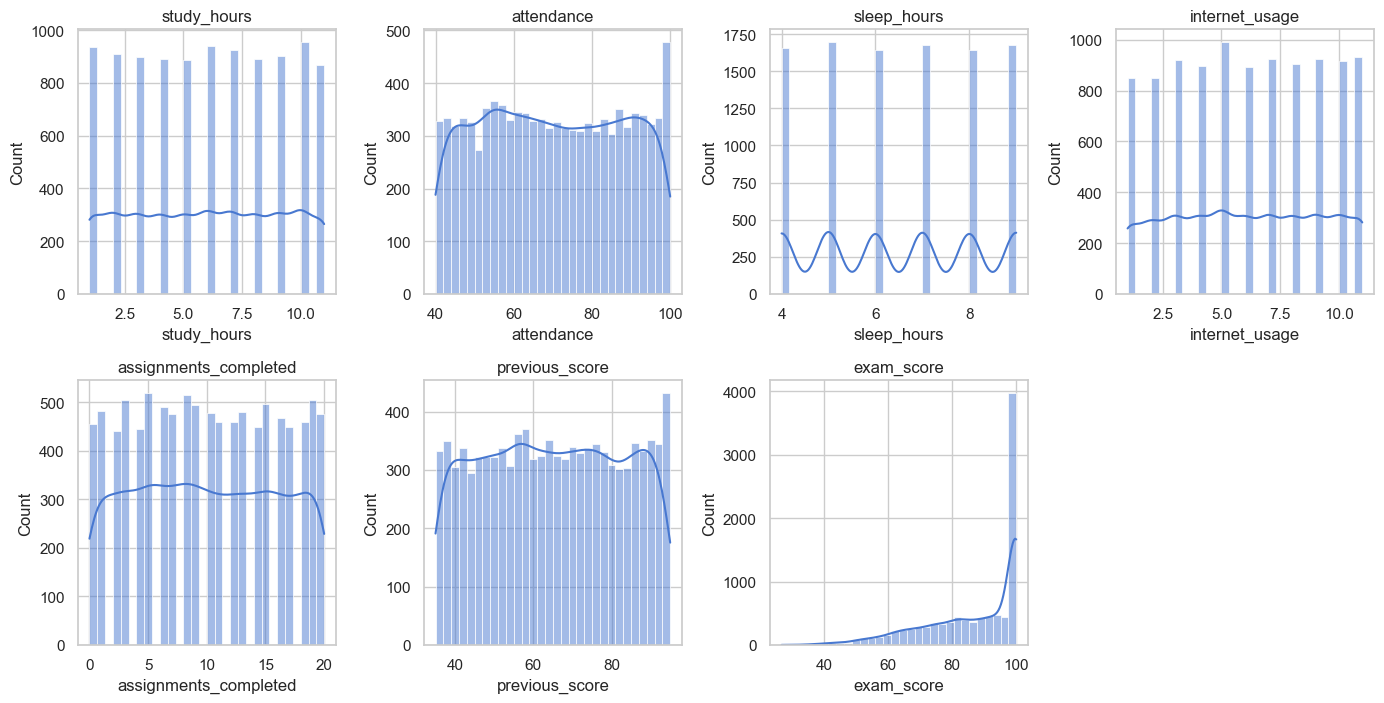

In [2]:
for col in CAT_COLS:
    vc = df[col].value_counts()
    tab = pd.DataFrame({"count": vc, "pct": (vc / len(df) * 100).round(1)})
    print(f"\n=== {col} ===")
    display(tab)

display(df[NUM_COLS].describe().T)

n = len(NUM_COLS)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows))
axes = np.atleast_1d(axes).ravel()
for i, col in enumerate(NUM_COLS):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)
for j in range(len(NUM_COLS), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


## Multivariate analysis

- Numeric vs numeric: correlation heatmap among behaviors, **previous_score**, and **exam_score**.
- Categorical vs numeric: boxplots of key outcomes by **placement_status**.
- Binned **attendance** vs **placement_status**: row-normalized crosstab (pseudo “two categorical” view on ordered attendance).

**Agent read:** compare correlation strengths involving **exam_score** and **previous_score** to which habits move jointly vs independently; use boxplots to see whether placement aligns with higher scores or study patterns.


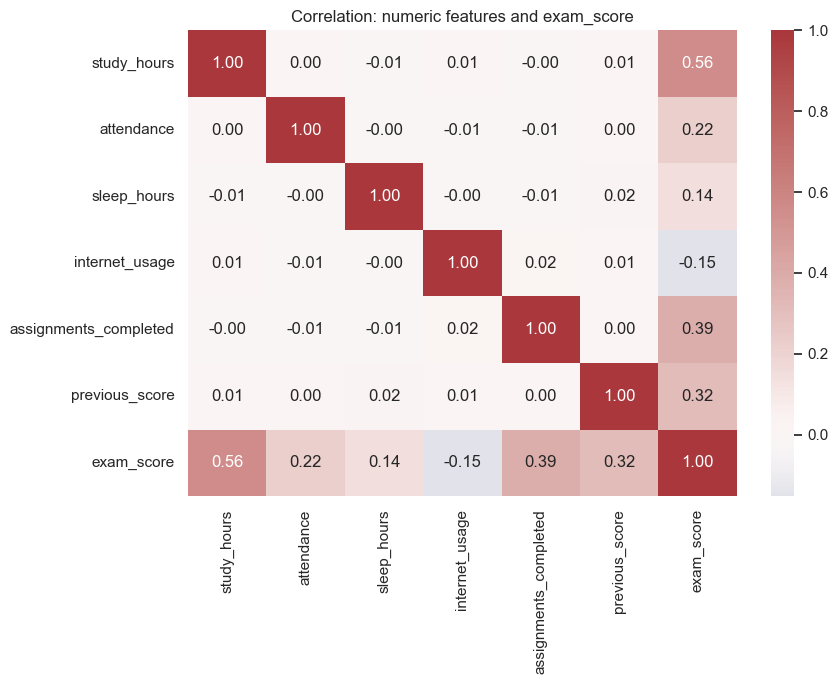

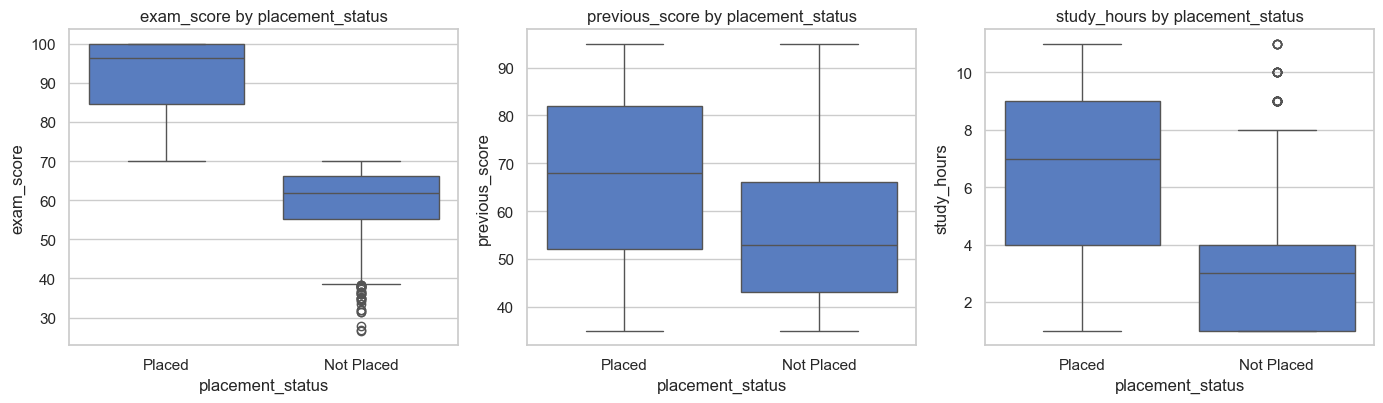

Row % within attendance band (Placed vs Not Placed)


placement_status,Not Placed,Placed
attendance_band,,
low_attendance,24.3,75.7
mid_attendance,15.7,84.3
high_attendance,8.8,91.2


In [3]:
corr = df[NUM_COLS].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation: numeric features and exam_score")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col in zip(axes, ["exam_score", "previous_score", "study_hours"]):
    sns.boxplot(data=df, x="placement_status", y=col, ax=ax)
    ax.set_title(f"{col} by placement_status")
plt.tight_layout()
plt.show()

df = df.copy()
df["attendance_band"] = pd.qcut(
    df["attendance"], q=3, labels=["low_attendance", "mid_attendance", "high_attendance"]
)
ct = pd.crosstab(df["attendance_band"], df["placement_status"], normalize="index") * 100
print("Row % within attendance band (Placed vs Not Placed)")
display(ct.round(1))


## Takeaways (for modeling)

- **Leakage check:** if **exam_score** is the prediction target, exclude it from feature columns; if **placement_status** is the target, keep **exam_score** as a candidate feature only if it is observed *before* the placement outcome in the real process.
- **Class imbalance:** ~83.6% Placed vs ~16.4% Not Placed — use stratified splits and metrics beyond accuracy (PR-AUC, recall on the minority class) if the business cares about catching "Not Placed".
- **Next steps:** baseline logistic regression or tree model on numeric habits + **previous_score**; partial dependence or SHAP on the strongest correlates to narrate drivers.
